In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\chilco\Export_cgq270.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8908 entries, 0 to 8907
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  8908 non-null   str  
 1   Message  8908 non-null   str  
 2   Status   8908 non-null   str  
dtypes: str(3)
memory usage: 208.9 KB


Odometer

In [6]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

#print(unit)

260601004813  ->  0 17494214.0 0x252513005924810869487061675582003C0E102D000000565000000007000020000000FFFFFFFFFFFFFFFFFFFF00D5010AF0C69126060100481333339F44971698C21AFBEE3F000000E003871248FFFFFF00001A0000FFFFFF
260601014813  ->  1 17494214.0 0x252513005924820869487061675582003C0E102D0000005D4F00000007000020000000FFFFFFFFFFFFFFFFFFFF00D5010AF0C69026060101481333339F44971698C21AFBEE3F000000E003871248FFFFFF0000190000FFFFFF
260601024812  ->  2 17494214.0 0x252513005924830869487061675582003C0E102D0000005D5000000007000020000000FFFFFFFFFFFFFFFFFFFF00D5010AF0C68926060102481233339F44971698C21AFBEE3F000000E003871246FFFFFF0000170000FFFFFF
260601034813  ->  3 17494214.0 0x252513005924840869487061675582003C0E102D000000595000000007000020000000FFFFFFFFFFFFFFFFFFFF00D5010AF0C69026060103481333339F44971698C21AFBEE3F000000E003871246FFFFFF0000170000FFFFFF
260601044813  ->  4 17494214.0 0x252513005924850869487061675582003C0E102D0000004F4E00000007000020000000FFFFFFFFFFFFFFFFFFFF00D5010AF0C690260601044813333

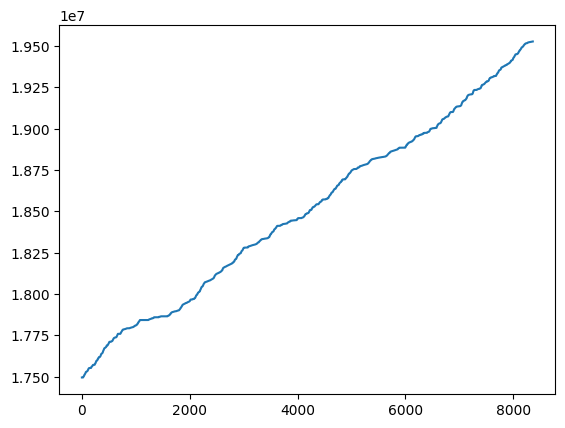

In [7]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,3]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,4])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],' -> ',x_axis[i],y_axis[i],raw_data_[i])

print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [9]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    speed.append(int(unit_aux.iloc[i,2][142:145],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Speed']=speed
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

#print(unit)

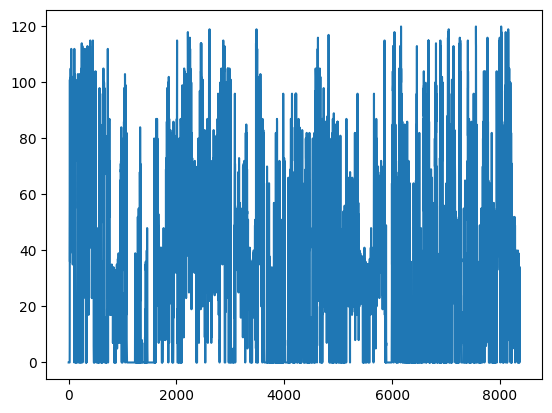

In [10]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,4])

plt.plot(x_axis,y_axis)

Mileage report from Ignition 01-06-2026 to 01-07-2026 because Ignition only let me download in this period.

In [13]:
mr=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\chilco\mileageReport_cgq270.csv',sep=',')
mr.info()

<class 'pandas.DataFrame'>
RangeIndex: 4589 entries, 0 to 4588
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unit                 4589 non-null   str    
 1   Time/Date (UTC-5)    4589 non-null   str    
 2   Address              4589 non-null   str    
 3   Distance (km)        4589 non-null   float64
 4   Total Distance (km)  4589 non-null   float64
 5   Odometer             4589 non-null   float64
 6   Driver               0 non-null      float64
dtypes: float64(4), str(3)
memory usage: 251.1 KB


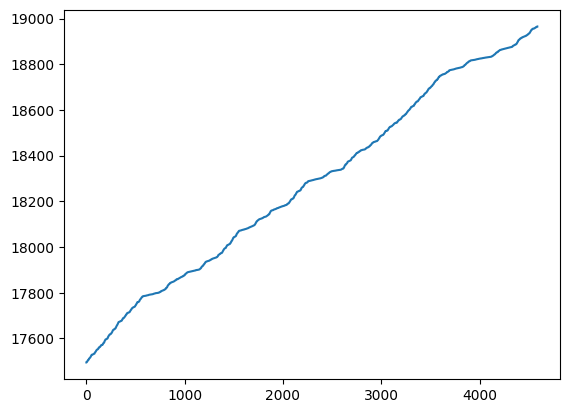

In [15]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,mr.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(mr.iloc[i,5]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])

plt.plot(x_axis,y_axis)